<a href="https://colab.research.google.com/github/nurahmi-tintyasusi-dev/data-science-2026/blob/main/Pertemuan5_Nurahmi_Tintyasusi_250401020035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : NURAHMI TINTYASUSI

NIM : 250401020035

Kelas : IF401

Mata Kuliah : Data Science


---
# DASHBOARD VISUALISASI STATIS

Import library visualisasi

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


Load dataset Tips

(244, 7)
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


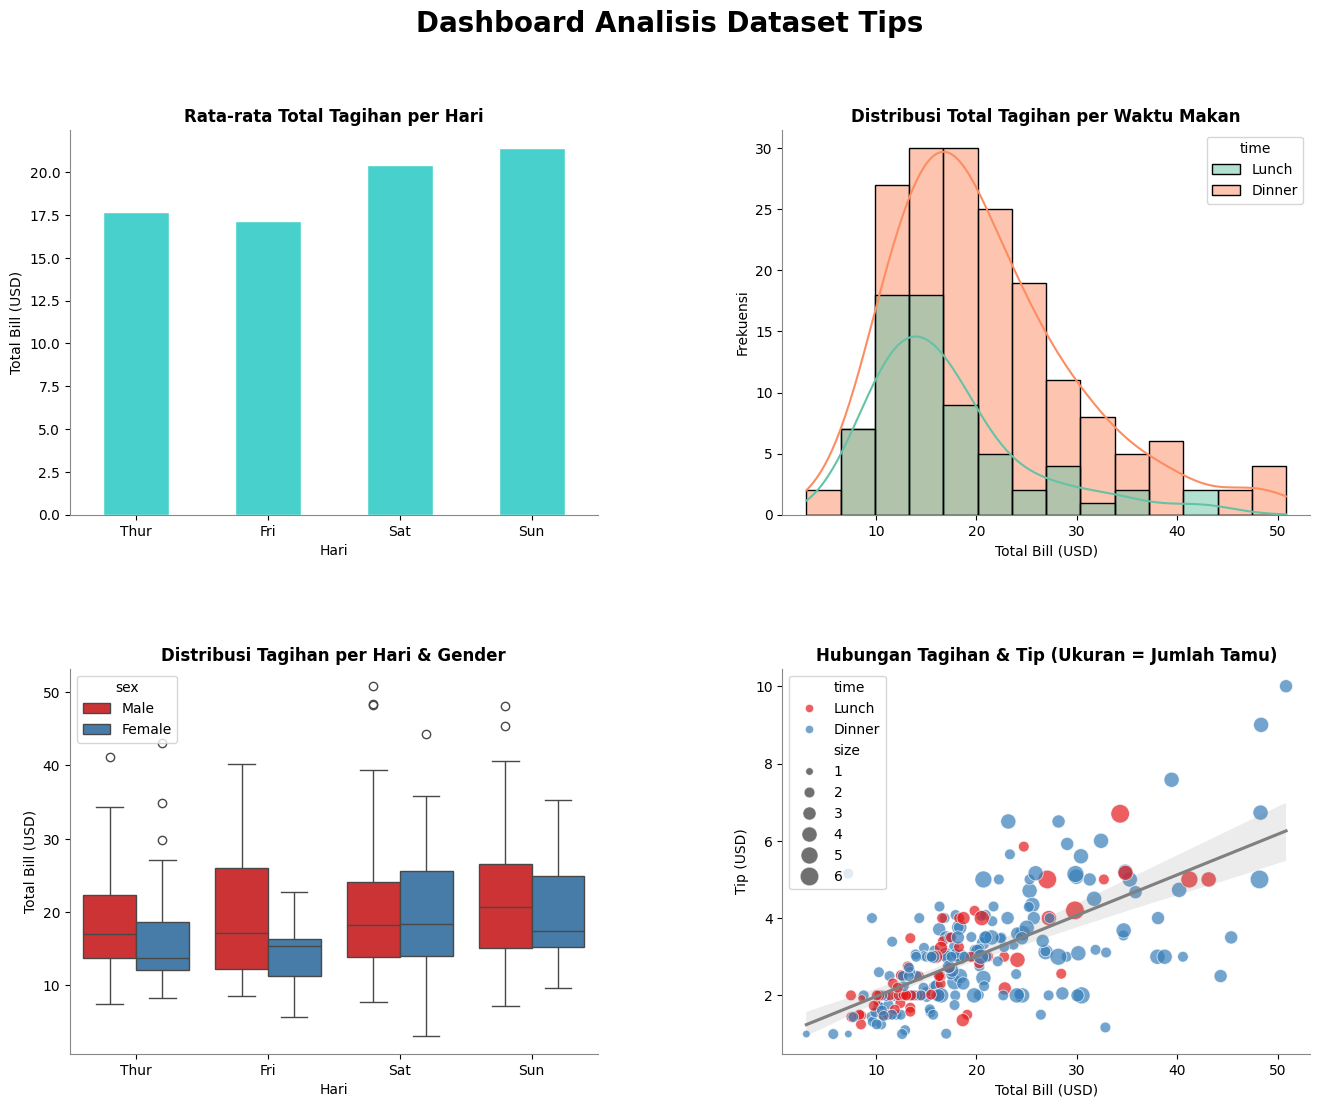

Dashboard tersimpan sebagai dashboard_tips.png


In [123]:
df_t = sns.load_dataset('tips')
print(df_t.shape)
print(df_t.dtypes)
print(df_t.describe().round(2))


#Setup layout dashboard
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=20, fontweight='bold', y=0.98)

# Grid 2 X 2 Subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

#Grafik 1: Bar chart rata-rata tagihan per hari

rata_harian = df_t.groupby('day', observed=False)['total_bill'].mean()
rata_harian.plot(kind='bar', ax=ax1, color='#48D1CC', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

#Grafik 2: Histogram distribusi tagihan

sns.histplot(data=df_t, x='total_bill', hue='time', kde=True,
             palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=12,fontweight='bold')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Frekuensi')
ax2.tick_params(axis='x', rotation=0)
ax2.spines[['top', 'right']].set_visible(False)

#Grafik 3: Boxplot tagihan per hari dan gender
sns.boxplot(data=df_t, x='day', y='total_bill', hue='sex',
            palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=12,fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)

#Grafik 4: Scatter plot hubungan tagihan dan tip
sns.scatterplot(data=df_t, x='total_bill', y='tip', hue='time',
                size='size', sizes=(30, 180), palette='Set1', alpha=0.7, ax=ax4)
sns.regplot(data=df_t, x='total_bill', y='tip', scatter=False,
            color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=12,fontweight='bold')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)

#Simpan dashboard
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
plt.savefig('./dashboard_tips.png', dpi=300, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')


# KESIMPULAN



*   **Apa yang dipelajari:** Membuat grafik dasar (Matplotlib) dan grafik statistik yang lebih estetis (Seaborn) menggunakan Python, termasuk pemahaman arsitektur Figure dan Axes.
*   **Temuan Utama:** Evaluasi grafik tidak boleh berhenti pada apa yang tertulis (What), melainkan harus menggali signifikansi bisnisnya (So what) dan merumuskan rekomendasi aksi konkret (Now what).
*   **Keterbatasan/Pertanyaan:** Bagaimana menentukan batas toleransi kategori yang objektif sebelum beralih dari Pie Chart ke Bar Chart jika terdapat beberapa kategori yang memiliki proporsi sangat mikro?

